Name-Riya choudhary

Subject-Computer vision Lab

CUID-CU24250251

**Experiment No. 2**

Contrast Enhancement and Histogram-Based Image Processing using Python and OpenCV

 #Step 1: Import the required libraries

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


 #Step 2: Load a low-contrast grayscale image (or convert color -> grayscale)

Saving ChatGPT Image Sep 4, 2026, 01_32_35 AM.png to ChatGPT Image Sep 4, 2026, 01_32_35 AM.png
Image loaded successfully!
Image file: ChatGPT Image Sep 4, 2026, 01_32_35 AM.png


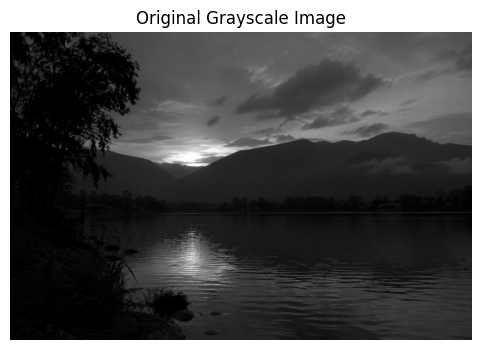

In [12]:
from google.colab import files

uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]

img = cv2.imread(IMAGE_PATH)

if img is None:
    print("Error: Image could not be loaded.")
else:
    print("Image loaded successfully!")
    print("Image file:", IMAGE_PATH)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(7, 4))
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

 #Step 3: Display the original image and generate its histogram

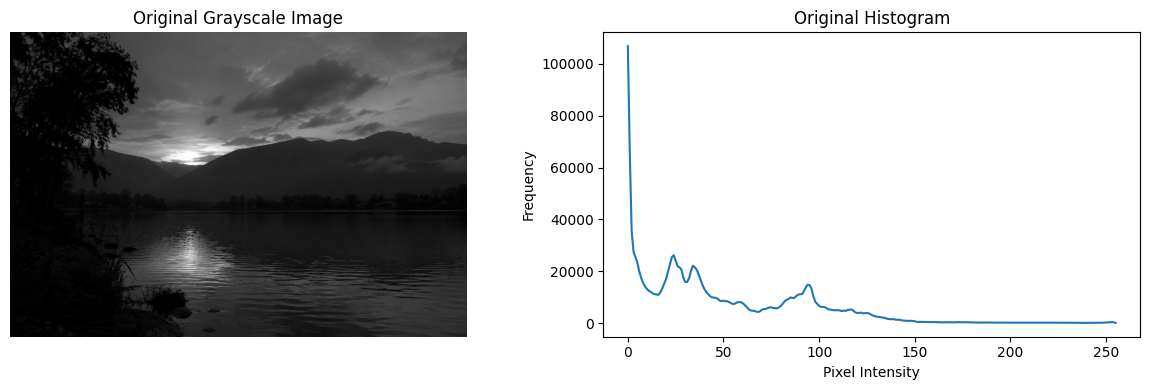

In [13]:
hist_original = cv2.calcHist([gray], [0], None, [256], [0, 256])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original Grayscale Image")
axes[0].axis("off")

axes[1].plot(hist_original)
axes[1].set_title("Original Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

 #Step 4: Contrast stretching to improve the dynamic range

Original intensity range: [np.uint8(0), np.uint8(255)]
Stretched intensity range: [np.uint8(0), np.uint8(255)]


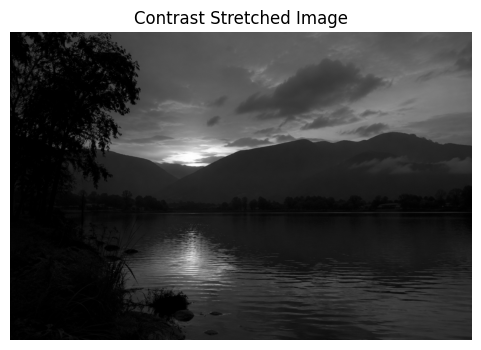

In [14]:
min_val = np.min(gray)
max_val = np.max(gray)

stretched = (
    (gray.astype(np.float32) - min_val)
    * 255.0
    / (max_val - min_val)
)

stretched = np.clip(stretched, 0, 255).astype(np.uint8)

print("Original intensity range:", [min_val, max_val])
print("Stretched intensity range:", [stretched.min(), stretched.max()])

plt.figure(figsize=(6, 4))
plt.imshow(stretched, cmap="gray")
plt.title("Contrast Stretched Image")
plt.axis("off")
plt.show()

 #Step 5: Histogram Equalization and comparison with original

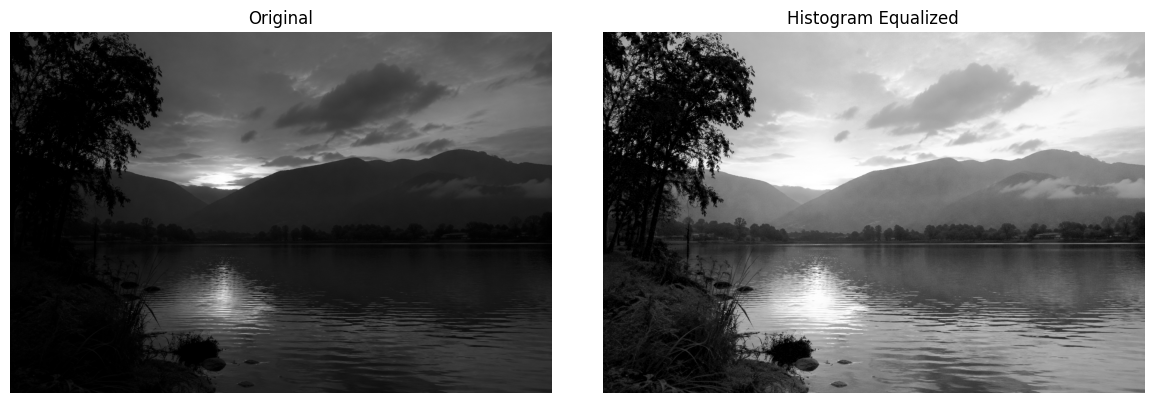

In [15]:
equalized = cv2.equalizeHist(gray)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(equalized, cmap="gray")
axes[1].set_title("Histogram Equalized")
axes[1].axis("off")

plt.tight_layout()
plt.show()

  #Step 6: CLAHE (Contrast Limited Adaptive Histogram Equalization)

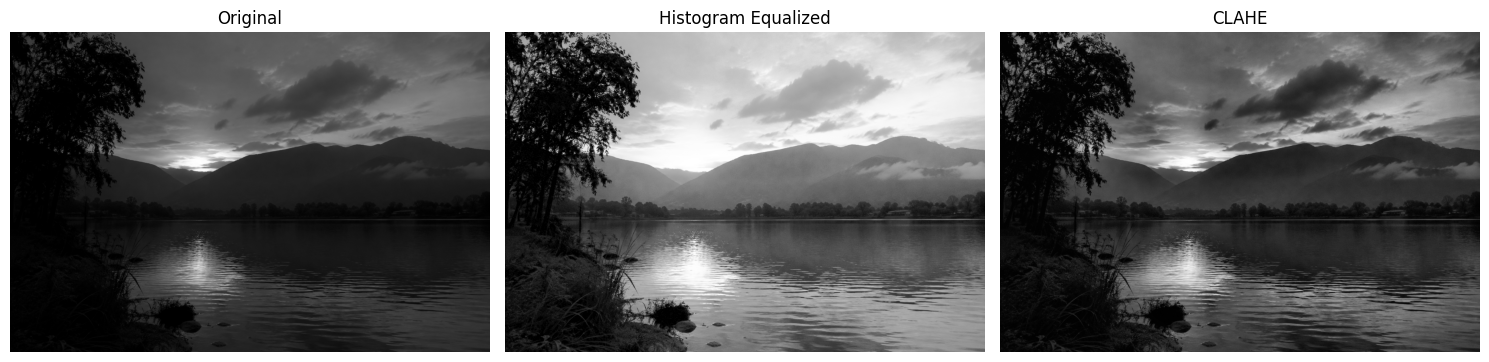

In [16]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

clahe_img = clahe.apply(gray)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(equalized, cmap="gray")
axes[1].set_title("Histogram Equalized")
axes[1].axis("off")

axes[2].imshow(clahe_img, cmap="gray")
axes[2].set_title("CLAHE")
axes[2].axis("off")

plt.tight_layout()
plt.show()

  #Step 7: Plot and compare histograms of original, equalized, and CLAHE images

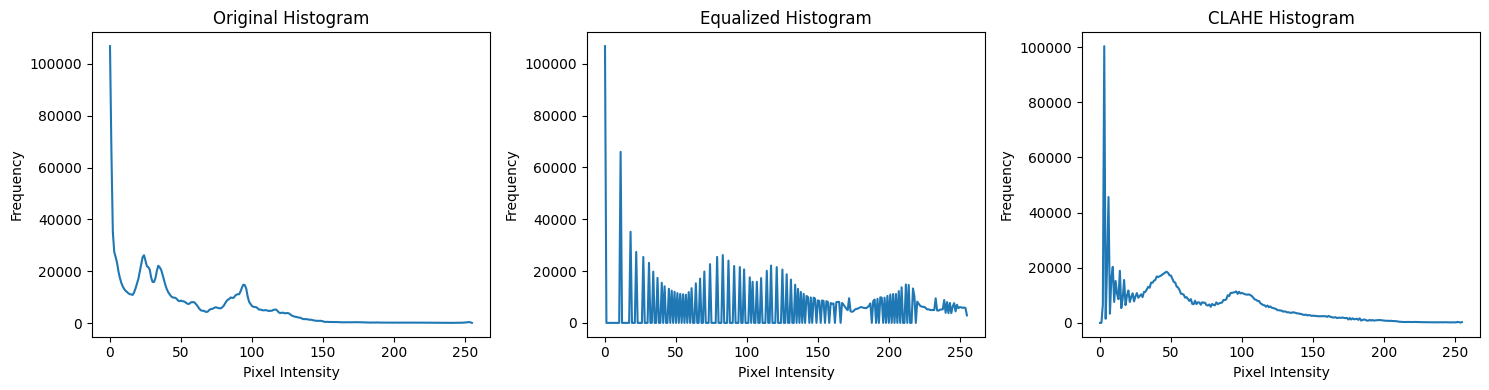

In [17]:
hist_equalized = cv2.calcHist(
    [equalized], [0], None, [256], [0, 256]
)

hist_clahe = cv2.calcHist(
    [clahe_img], [0], None, [256], [0, 256]
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist_original)
axes[0].set_title("Original Histogram")

axes[1].plot(hist_equalized)
axes[1].set_title("Equalized Histogram")

axes[2].plot(hist_clahe)
axes[2].set_title("CLAHE Histogram")

for ax in axes:
    ax.set_xlabel("Pixel Intensity")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

 #Step 8: Analyze visual improvements (brightness, contrast, feature visibility)

In [18]:
def summarize(name, image):
    print(
        f"{name:20s} | "
        f"Mean: {image.mean():7.2f} | "
        f"Contrast (Std): {image.std():7.2f} | "
        f"Min: {image.min():3d} | "
        f"Max: {image.max():3d}"
    )

print("Quantitative Comparison")
print("-----------------------")

summarize("Original", gray)
summarize("Contrast Stretched", stretched)
summarize("Histogram Equalized", equalized)
summarize("CLAHE", clahe_img)

Quantitative Comparison
-----------------------
Original             | Mean:   47.39 | Contrast (Std):   42.43 | Min:   0 | Max: 255
Contrast Stretched   | Mean:   47.39 | Contrast (Std):   42.43 | Min:   0 | Max: 255
Histogram Equalized  | Mean:  120.17 | Contrast (Std):   77.46 | Min:   0 | Max: 255
CLAHE                | Mean:   65.55 | Contrast (Std):   49.24 | Min:   1 | Max: 255


  #Step 9: Compare effectiveness of Histogram Equalization vs CLAHE


In [19]:
print("Comparison: Histogram Equalization vs CLAHE")
print("--------------------------------------------")

print(f"Histogram Equalization contrast: {equalized.std():.2f}")
print(f"CLAHE contrast: {clahe_img.std():.2f}")

print("\nHistogram Equalization:")
print("It applies a single global intensity transformation.")
print("It can improve overall contrast but may over-enhance some regions.")

print("\nCLAHE:")
print("It performs local contrast enhancement using small image regions.")
print("It usually provides better enhancement when illumination varies across the image.")

Comparison: Histogram Equalization vs CLAHE
--------------------------------------------
Histogram Equalization contrast: 77.46
CLAHE contrast: 49.24

Histogram Equalization:
It applies a single global intensity transformation.
It can improve overall contrast but may over-enhance some regions.

CLAHE:
It performs local contrast enhancement using small image regions.
It usually provides better enhancement when illumination varies across the image.


 #Step 10: Document observations

In [20]:
print("Observations")
print("------------")

print("- The original histogram represents the distribution of pixel intensities.")
print("- Contrast stretching expands the intensity range and improves overall contrast.")
print("- Histogram Equalization redistributes pixel intensities and provides strong global contrast enhancement.")
print("- CLAHE performs local contrast enhancement and preserves details in different image regions.")
print("- Histogram Equalization is useful for overall contrast improvement.")
print("- CLAHE is generally more suitable for images with varying illumination.")
print("- Histogram-based enhancement techniques improve visibility and feature representation.")

Observations
------------
- The original histogram represents the distribution of pixel intensities.
- Contrast stretching expands the intensity range and improves overall contrast.
- Histogram Equalization redistributes pixel intensities and provides strong global contrast enhancement.
- CLAHE performs local contrast enhancement and preserves details in different image regions.
- Histogram Equalization is useful for overall contrast improvement.
- CLAHE is generally more suitable for images with varying illumination.
- Histogram-based enhancement techniques improve visibility and feature representation.
